# Анализ временных рядов. Проект.

**Выполнил**: Завьялов Егор Сергеевич

**Гипотеза**: Нормализация по рядам особенно важна для глобальных нейронных
моделей, но влияет неоднозначно для моделей из разных классов.

**Данные**: M4 Competition monthly subset (300 series)  
**Baselines**: Naive, SeasonalNaive, Auto.Theta, Auto.ETS  
**Models**: Naive, SeasonalNaive, CatBoost, LSTM  
**Scaling**: none / standard / robust / quantile  
**Metrics**: MAE, sMAPE

## 1. Конфигурация зависимостей проекта

In [1]:
!pip install -q catboost statsmodels seaborn torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from catboost import CatBoostRegressor
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sample_n = 300
input_size = 24
horizon = 18
random_state = SEED

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Sample size: {sample_n}")
print(f"Input size: {input_size}, Horizon: {horizon}")
print(f"Full reproducibility seed: {SEED}")

Device: cuda
Sample size: 300
Input size: 24, Horizon: 18
Full reproducibility seed: 42


## 2. Загрузка данных(M4 Monthly Data)

In [3]:
!wget -q https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Train/Monthly-train.csv
!wget -q https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Test/Monthly-test.csv
!wget -q https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/M4-info.csv

In [4]:
train_df = pd.read_csv("Monthly-train.csv")
test_df = pd.read_csv("Monthly-test.csv")
info_df = pd.read_csv("M4-info.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Info shape: {info_df.shape}")

Train shape: (48000, 2795)
Test shape: (48000, 19)
Info shape: (100000, 6)


## 3. Sample Subset and Convert to Series

In [5]:
def row_to_series(row):
    values = row.drop("V1").dropna().astype(float).tolist()
    return values

sample_ids = train_df["V1"].sample(sample_n, random_state=random_state).tolist()

train_sample = train_df[train_df["V1"].isin(sample_ids)].copy()
test_sample = test_df[test_df["V1"].isin(sample_ids)].copy()
info_sample = info_df[info_df["M4id"].isin(sample_ids)].copy()

series_dict = {
    row["V1"]: row_to_series(row) for _, row in train_sample.iterrows()
}

test_dict = {
    row["V1"]: row_to_series(row) for _, row in test_sample.iterrows()
}

first_id = list(series_dict.keys())[0]
print(f"Sample series: {len(series_dict)}")
print(f"Train length: {len(series_dict[first_id])}")
print(f"Test horizon: {len(test_dict[first_id])}")

Sample series: 300
Train length: 112
Test horizon: 18


## 4. Метрики

In [6]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / np.where(denom == 0, 1e-8, denom))

## 5. Бейзлайн-решения

### 5.1 Все бейзлайны

In [38]:
def naive_forecast(train_series, horizon):
    return np.repeat(train_series[-1], horizon)

def seasonal_naive_forecast(train_series, horizon, season_length=12):
    last_season = train_series[-season_length:]
    reps = int(np.ceil(horizon / season_length))
    forecast = np.tile(last_season, reps)[:horizon]
    return forecast

def auto_theta_forecast(train_series, horizon):
    ts = pd.Series(train_series)
    theta_model = ThetaModel(ts, period=12)
    theta_fit = theta_model.fit()
    forecast = theta_fit.forecast(horizon)
    return np.array(forecast)

def auto_ets_forecast(train_series, horizon, season_length=12):
    ts = pd.Series(train_series)
    best_fit = None
    best_aic = np.inf

    configs = [
        {"trend": None, "seasonal": None, "damped_trend": False},
        {"trend": "add", "seasonal": None, "damped_trend": False},
        {"trend": "add", "seasonal": None, "damped_trend": True},
        {"trend": None, "seasonal": "add", "damped_trend": False},
        {"trend": "add", "seasonal": "add", "damped_trend": False},
        {"trend": "add", "seasonal": "add", "damped_trend": True},
    ]

    for cfg in configs:
        try:
            seasonal_periods = season_length if cfg["seasonal"] is not None else None

            model = ExponentialSmoothing(
                ts,
                trend=cfg["trend"],
                seasonal=cfg["seasonal"],
                damped_trend=cfg["damped_trend"],
                seasonal_periods=seasonal_periods,
                initialization_method="estimated",
            )

            fit = model.fit(optimized=True, use_brute=True)

            if np.isfinite(fit.aic) and fit.aic < best_aic:
                best_aic = fit.aic
                best_fit = fit

        except Exception:
            continue

    if best_fit is None:
        return naive_forecast(train_series, horizon)

    forecast = best_fit.forecast(horizon)
    return np.asarray(forecast, dtype=float)

### 5.2 Оценка бейзлайнз-решений

In [39]:
rows = []

for ts_id in sample_ids:
    y_train = series_dict[ts_id]
    y_test = test_dict[ts_id]
    h = len(y_test)

    pred_naive = naive_forecast(y_train, h)
    pred_snaive = seasonal_naive_forecast(y_train, h, season_length=12)
    pred_theta = auto_theta_forecast(y_train, h)
    pred_ets = auto_ets_forecast(y_train, h)

    rows.append({
        "id": ts_id,
        "model": "naive",
        "mae": mae(y_test, pred_naive),
        "smape": smape(y_test, pred_naive)
    })

    rows.append({
        "id": ts_id,
        "model": "seasonal_naive",
        "mae": mae(y_test, pred_snaive),
        "smape": smape(y_test, pred_snaive)
    })

    rows.append({
        "id": ts_id,
        "model": "auto_theta",
        "mae": mae(y_test, pred_theta),
        "smape": smape(y_test, pred_theta)
    })

    rows.append({
        "id": ts_id,
        "model": "auto_ets",
        "mae": mae(y_test, pred_ets),
        "smape": smape(y_test, pred_ets)
    })

results_df = pd.DataFrame(rows)
results_df.groupby("model")[["mae", "smape"]].mean()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_

,mae,smape
model,,
auto_ets,447.857170,11.618189
auto_theta,480.439963,11.798300
naive,584.830848,14.115631
seasonal_naive,582.659971,14.549141


## 6. CatBoost without Scaling

### 6.1 Lagged Dataset

In [40]:
def make_lagged_dataset(series_dict, input_size=24):
    rows = []

    for ts_id, values in series_dict.items():
        values = np.asarray(values, dtype=float)

        if len(values) <= input_size:
            continue

        for t in range(input_size, len(values)):
            row = {"id": ts_id, "target": values[t]}
            for lag in range(1, input_size + 1):
                row[f"lag_{lag}"] = values[t - lag]
            rows.append(row)

    return pd.DataFrame(rows)

lag_df = make_lagged_dataset(series_dict, input_size=input_size)
print(f"Shape: {lag_df.shape}")

Shape: (61111, 26)


### 6.2 Train CatBoost

In [41]:
feature_cols = [col for col in lag_df.columns if col.startswith("lag_")]

X_train = lag_df[feature_cols]
y_train = lag_df["target"]

cb_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="MAE",
    verbose=0,
    random_seed=42
)

cb_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=0)

### 6.3 Evaluate CatBoost

In [42]:
def recursive_catboost_forecast(model, train_series, horizon, input_size=24):
    history = list(train_series.copy())
    preds = []

    for _ in range(horizon):
        x = np.array(history[-input_size:][::-1], dtype=float)
        x_df = pd.DataFrame([{
            f"lag_{i+1}": x[i] for i in range(input_size)
        }])
        pred = model.predict(x_df)[0]
        preds.append(pred)
        history.append(pred)

    return np.array(preds)

In [43]:
rows = []

for ts_id in sample_ids:
    y_train = series_dict[ts_id]
    y_test = test_dict[ts_id]
    h = len(y_test)

    pred_cb = recursive_catboost_forecast(cb_model, y_train, h, input_size=input_size)

    rows.append({
        "id": ts_id,
        "model": "catboost_none",
        "mae": mae(y_test, pred_cb),
        "smape": smape(y_test, pred_cb)
    })

cb_results = pd.DataFrame(rows)
cb_results.groupby("model")[["mae", "smape"]].mean()

,mae,smape
model,,
catboost_none,536.741856,13.5859


## 7. LSTM without Scaling

### 7.1 Dataset

In [44]:
class GlobalWindowDataset(Dataset):
    def __init__(self, series_dict, input_size=24, horizon=18):
        self.X = []
        self.y = []

        for ts_id, values in series_dict.items():
            values = np.asarray(values, dtype=np.float32)

            if len(values) < input_size + horizon:
                continue

            for start in range(len(values) - input_size - horizon + 1):
                x = values[start : start + input_size]
                y = values[start + input_size : start + input_size + horizon]

                self.X.append(x)
                self.y.append(y)

        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx]).unsqueeze(-1)
        y = torch.tensor(self.y[idx])
        return x, y

train_dataset = GlobalWindowDataset(series_dict, input_size=input_size, horizon=horizon)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, generator=g)

print(f"Train ssamples: {len(train_dataset)}")

Train ssamples: 56011


### 7.2 LSTM Model

In [45]:
class GlobalLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, horizon=18, dropout=0.1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.head = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        forecast = self.head(last_hidden)
        return forecast

model = GlobalLSTM(
    input_dim=1,
    hidden_dim=32,
    num_layers=2,
    horizon=horizon,
    dropout=0.1
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Params: {sum(p.numel() for p in model.parameters())}")

Params: 13522


### 7.3 Train LSTM

In [46]:
epochs = 12 #если менять, то ниже для скейленых тожк
history = []

for epoch in range(epochs):
    model.train()
    epoch_losses = []

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        epoch_losses.append(loss.item())

    mean_loss = np.mean(epoch_losses)
    history.append(mean_loss)
    print(f"Epoch {epoch+1}/{epochs}, loss={mean_loss:.4f}")

Epoch 1/12, loss=4455.2753
Epoch 2/12, loss=4425.5774
Epoch 3/12, loss=4397.9143
Epoch 4/12, loss=4367.7071
Epoch 5/12, loss=4339.1791
Epoch 6/12, loss=4309.2821
Epoch 7/12, loss=4280.3466
Epoch 8/12, loss=4252.5313
Epoch 9/12, loss=4222.0712
Epoch 10/12, loss=4195.3666
Epoch 11/12, loss=4167.0941
Epoch 12/12, loss=4136.6072


### 7.4 Evaluate LSTM

In [47]:
def lstm_direct_forecast(model, train_series, input_size=24, device="cpu"):
    model.eval()

    x = np.asarray(train_series[-input_size:], dtype=np.float32)
    x = torch.tensor(x).unsqueeze(0).unsqueeze(-1).to(device)

    with torch.no_grad():
        pred = model(x).cpu().numpy().flatten()

    return pred

rows = []

for ts_id in sample_ids:
    y_train = series_dict[ts_id]
    y_test = test_dict[ts_id]

    if len(y_train) < input_size:
        continue

    pred_nn = lstm_direct_forecast(model, y_train, input_size=input_size, device=device)

    rows.append({
        "id": ts_id,
        "model": "lstm_none",
        "mae": mae(y_test, pred_nn),
        "smape": smape(y_test, pred_nn)
    })

nn_results = pd.DataFrame(rows)
nn_results.groupby("model")[["mae", "smape"]].mean()

,mae,smape
model,,
lstm_none,4403.935468,154.933281


## 8. LSTM No-Scaling детально

In [48]:
ts_id = sample_ids[0]
y_train = series_dict[ts_id]
y_test = test_dict[ts_id]

pred_nn = lstm_direct_forecast(model, y_train, input_size=input_size, device=device)

print(f"Series {ts_id}:")
print(f"Train last 5: {y_train[-5:]}")
print(f"Test first 5: {y_test[:5]}")
print(f"Pred first 5: {pred_nn[:5]}")

Series M32772:
Train last 5: [2876.716616, 3290.831311, 3007.943854, 2984.62421, 3316.54397]
Test first 5: [3241.574288, 3169.448365, 3245.72773, 2632.132877, 2387.522125]
Pred first 5: [349.10446 348.99704 348.9002  348.88568 349.28665]


## 9. Scaling

In [49]:
def scale_series_dict(series_dict, scaler_type="standard"):
    scaled_dict = {}
    scalers = {}

    for ts_id, values in series_dict.items():
        arr = np.asarray(values, dtype=np.float32).reshape(-1, 1)

        if scaler_type == "standard":
            scaler = StandardScaler()
        elif scaler_type == "robust":
            scaler = RobustScaler()
        elif scaler_type == "quantile":
            n_quantiles = min(100, len(arr))
            scaler = QuantileTransformer(
                output_distribution="normal",
                n_quantiles=n_quantiles,
                random_state=42
            )
        else:
            raise ValueError(f"Unknown: {scaler_type}")

        scaled = scaler.fit_transform(arr).flatten().astype(np.float32)
        scaled_dict[ts_id] = scaled
        scalers[ts_id] = scaler

    return scaled_dict, scalers


def inverse_transform_forecast(forecast, scaler):
    forecast = np.asarray(forecast).reshape(-1, 1)
    return scaler.inverse_transform(forecast).flatten()


print("Scaling is applied separately to each train series.")

Scaling is applied separately to each train series.


## 10. CatBoost with Scaling

### 10.1 Helper funcs

In [50]:
def train_catboost_on_series_dict(series_dict_scaled, input_size=24):
    lag_df = make_lagged_dataset(series_dict_scaled, input_size=input_size)
    feature_cols = [c for c in lag_df.columns if c.startswith("lag_")]

    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="MAE",
        verbose=0,
        random_seed=42
    )

    model.fit(lag_df[feature_cols], lag_df["target"])
    return model


def recursive_catboost_forecast_scaled(model, train_series, horizon, input_size=24):
    history = list(np.asarray(train_series, dtype=float).copy())
    preds = []

    for _ in range(horizon):
        last_window = history[-input_size:]
        x_df = pd.DataFrame([{
            f"lag_{i+1}": last_window[-(i+1)] for i in range(input_size)
        }])
        pred = model.predict(x_df)[0]
        preds.append(pred)
        history.append(pred)

    return np.array(preds, dtype=float)


def evaluate_catboost_scaled(model, scaled_series_dict, original_test_dict, scalers, sample_ids, model_name, input_size=24):
    rows = []

    for ts_id in sample_ids:
        y_train_scaled = scaled_series_dict[ts_id]
        y_test = original_test_dict[ts_id]
        h = len(y_test)

        pred_scaled = recursive_catboost_forecast_scaled(
            model,
            y_train_scaled,
            h,
            input_size=input_size
        )

        pred = inverse_transform_forecast(pred_scaled, scalers[ts_id])

        rows.append({
            "id": ts_id,
            "model": model_name,
            "mae": mae(y_test, pred),
            "smape": smape(y_test, pred)
        })

    return pd.DataFrame(rows)

### 10.2 Standard / Robust / Quantile

In [51]:
scaled_series_standard, standard_scalers = scale_series_dict(series_dict, "standard")
scaled_series_robust, robust_scalers = scale_series_dict(series_dict, "robust")
scaled_series_quantile, quantile_scalers = scale_series_dict(series_dict, "quantile")

print("Scaled series prepared.")

Scaled series prepared.


In [52]:
cb_standard_model = train_catboost_on_series_dict(scaled_series_standard, input_size=input_size)
cb_standard_results = evaluate_catboost_scaled(
    cb_standard_model,
    scaled_series_standard,
    test_dict,
    standard_scalers,
    sample_ids,
    model_name="catboost_standard",
    input_size=input_size
)

print("CatBoost Standard:")
print(cb_standard_results.groupby("model")[["mae", "smape"]].mean())

CatBoost Standard:
                          mae      smape
model                                   
catboost_standard  509.170267  12.509674


In [53]:
cb_robust_model = train_catboost_on_series_dict(scaled_series_robust, input_size=input_size)
cb_robust_results = evaluate_catboost_scaled(
    cb_robust_model,
    scaled_series_robust,
    test_dict,
    robust_scalers,
    sample_ids,
    model_name="catboost_robust",
    input_size=input_size
)

print("CatBoost Robust:")
print(cb_robust_results.groupby("model")[["mae", "smape"]].mean())

CatBoost Robust:
                        mae      smape
model                                 
catboost_robust  525.235333  12.874562


In [54]:
cb_quantile_model = train_catboost_on_series_dict(scaled_series_quantile, input_size=input_size)
cb_quantile_results = evaluate_catboost_scaled(
    cb_quantile_model,
    scaled_series_quantile,
    test_dict,
    quantile_scalers,
    sample_ids,
    model_name="catboost_quantile",
    input_size=input_size
)

print("CatBoost Quantile:")
print(cb_quantile_results.groupby("model")[["mae", "smape"]].mean())

CatBoost Quantile:
                          mae      smape
model                                   
catboost_quantile  529.202198  12.934245


In [55]:
catboost_all = pd.concat([cb_results, cb_standard_results, cb_robust_results, cb_quantile_results], ignore_index=True)
print("CatBoost All:")
print(catboost_all.groupby("model")[["mae", "smape"]].mean())

CatBoost All:
                          mae      smape
model                                   
catboost_none      536.741856  13.585900
catboost_quantile  529.202198  12.934245
catboost_robust    525.235333  12.874562
catboost_standard  509.170267  12.509674


## 11. LSTM with Scaling

### 11.1 Helper funcs

In [56]:
def train_lstm_on_series_dict(series_dict_scaled, input_size=24, horizon=18, epochs=12, batch_size=64, lr=1e-3, hidden_dim=32, device="cpu"):
    train_dataset = GlobalWindowDataset(
        series_dict_scaled,
        input_size=input_size,
        horizon=horizon
    )
    g = torch.Generator()
    g.manual_seed(SEED)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=g
    )

    model = GlobalLSTM(
        input_dim=1,
        hidden_dim=hidden_dim,
        num_layers=2,
        horizon=horizon,
        dropout=0.1
    ).to(device)

    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        history.append(mean_loss)
        print(f"Epoch {epoch+1}/{epochs}, loss={mean_loss:.4f}")

    return model, history


def evaluate_lstm_scaled(model, scaled_series_dict, original_test_dict, scalers, sample_ids, model_name, input_size=24, device="cpu"):
    rows = []

    for ts_id in sample_ids:
        y_train_scaled = scaled_series_dict[ts_id]
        y_test = original_test_dict[ts_id]

        pred_scaled = lstm_direct_forecast(
            model,
            y_train_scaled,
            input_size=input_size,
            device=device
        )

        pred = inverse_transform_forecast(pred_scaled, scalers[ts_id])

        rows.append({
            "id": ts_id,
            "model": model_name,
            "mae": mae(y_test, pred),
            "smape": smape(y_test, pred)
        })

    return pd.DataFrame(rows)

### 11.2 Standard / Robust / Quantile

In [57]:
print("Training LSTM Standard...")
lstm_standard_model, lstm_standard_history = train_lstm_on_series_dict(
    scaled_series_standard,
    input_size=input_size,
    horizon=horizon,
    epochs=12,
    batch_size=64,
    lr=1e-3,
    hidden_dim=32,
    device=device
)

lstm_standard_results = evaluate_lstm_scaled(
    lstm_standard_model,
    scaled_series_standard,
    test_dict,
    standard_scalers,
    sample_ids,
    model_name="lstm_standard",
    input_size=input_size,
    device=device
)

print("LSTM Standard:")
print(lstm_standard_results.groupby("model")[["mae", "smape"]].mean())

Training LSTM Standard...
Epoch 1/12, loss=0.3988
Epoch 2/12, loss=0.3550
Epoch 3/12, loss=0.3464
Epoch 4/12, loss=0.3400
Epoch 5/12, loss=0.3344
Epoch 6/12, loss=0.3293
Epoch 7/12, loss=0.3260
Epoch 8/12, loss=0.3231
Epoch 9/12, loss=0.3208
Epoch 10/12, loss=0.3187
Epoch 11/12, loss=0.3174
Epoch 12/12, loss=0.3161
LSTM Standard:
                      mae      smape
model                               
lstm_standard  564.920929  13.840543


In [58]:
print("Training LSTM Robust...")
lstm_robust_model, lstm_robust_history = train_lstm_on_series_dict(
    scaled_series_robust,
    input_size=input_size,
    horizon=horizon,
    epochs=12,
    batch_size=64,
    lr=1e-3,
    hidden_dim=32,
    device=device
)

lstm_robust_results = evaluate_lstm_scaled(
    lstm_robust_model,
    scaled_series_robust,
    test_dict,
    robust_scalers,
    sample_ids,
    model_name="lstm_robust",
    input_size=input_size,
    device=device
)

print("LSTM Robust:")
print(lstm_robust_results.groupby("model")[["mae", "smape"]].mean())

Training LSTM Robust...
Epoch 1/12, loss=0.2863
Epoch 2/12, loss=0.2564
Epoch 3/12, loss=0.2496
Epoch 4/12, loss=0.2452
Epoch 5/12, loss=0.2407
Epoch 6/12, loss=0.2375
Epoch 7/12, loss=0.2351
Epoch 8/12, loss=0.2335
Epoch 9/12, loss=0.2318
Epoch 10/12, loss=0.2310
Epoch 11/12, loss=0.2303
Epoch 12/12, loss=0.2294
LSTM Robust:
                    mae      smape
model                             
lstm_robust  555.092429  13.769951


In [59]:
print("Training LSTM Quantile...")
lstm_quantile_model, lstm_quantile_history = train_lstm_on_series_dict(
    scaled_series_quantile,
    input_size=input_size,
    horizon=horizon,
    epochs=12,
    batch_size=64,
    lr=1e-3,
    hidden_dim=32,
    device=device
)

lstm_quantile_results = evaluate_lstm_scaled(
    lstm_quantile_model,
    scaled_series_quantile,
    test_dict,
    quantile_scalers,
    sample_ids,
    model_name="lstm_quantile",
    input_size=input_size,
    device=device
)

print("LSTM Quantile:")
print(lstm_quantile_results.groupby("model")[["mae", "smape"]].mean())

Training LSTM Quantile...
Epoch 1/12, loss=0.4493
Epoch 2/12, loss=0.4088
Epoch 3/12, loss=0.3993
Epoch 4/12, loss=0.3929
Epoch 5/12, loss=0.3884
Epoch 6/12, loss=0.3846
Epoch 7/12, loss=0.3810
Epoch 8/12, loss=0.3780
Epoch 9/12, loss=0.3754
Epoch 10/12, loss=0.3732
Epoch 11/12, loss=0.3717
Epoch 12/12, loss=0.3702
LSTM Quantile:
                      mae      smape
model                               
lstm_quantile  737.077722  16.608314


In [60]:
lstm_all = pd.concat([nn_results, lstm_standard_results, lstm_robust_results, lstm_quantile_results], ignore_index=True)
print("LSTM All:")
print(lstm_all.groupby("model")[["mae", "smape"]].mean())

LSTM All:
                       mae       smape
model                                 
lstm_none      4403.935468  154.933281
lstm_quantile   737.077722   16.608314
lstm_robust     555.092429   13.769951
lstm_standard   564.920929   13.840543


## 12. Результаты

In [61]:
final_results = pd.concat([
    results_df,
    cb_results,
    nn_results,
    cb_standard_results,
    cb_robust_results,
    cb_quantile_results,
    lstm_standard_results,
    lstm_robust_results,
    lstm_quantile_results
], ignore_index=True)

summary_table = (
    final_results
    .groupby("model")[["mae", "smape"]]
    .mean()
    .sort_values("smape")
    .reset_index()
)

print("Final Results (by sMAPE):")
summary_table

Final Results (by sMAPE):


,model,mae,smape
0,auto_ets,447.857170,11.618189
1,auto_theta,480.439963,11.798300
2,catboost_standard,509.170267,12.509674
3,catboost_robust,525.235333,12.874562
4,catboost_quantile,529.202198,12.934245
5,catboost_none,536.741856,13.585900
6,lstm_robust,555.092429,13.769951
7,lstm_standard,564.920929,13.840543
8,naive,584.830848,14.115631
9,seasonal_naive,582.659971,14.549141


In [62]:
def split_model_name(name):
    if name == "naive":
        return "baseline", "none"
    if name == "seasonal_naive":
        return "baseline_seasonal", "none"
    if name == "auto_theta":
        return "baseline_theta", "none"
    if name == "auto_ets":
        return "baseline_ets", "none"

    parts = name.split("_")
    base_model = parts[0]
    scaling = "_".join(parts[1:]) if len(parts) > 1 else "none"
    return base_model, scaling

summary_table[["base_model", "scaling"]] = summary_table["model"].apply(
    lambda x: pd.Series(split_model_name(x))
)

summary_table = summary_table[[
    "model", "base_model", "scaling", "mae", "smape"
]].sort_values(["base_model", "scaling"])

summary_table

,model,base_model,scaling,mae,smape
8,naive,baseline,none,584.830848,14.115631
0,auto_ets,baseline_ets,none,447.857170,11.618189
9,seasonal_naive,baseline_seasonal,none,582.659971,14.549141
1,auto_theta,baseline_theta,none,480.439963,11.798300
5,catboost_none,catboost,none,536.741856,13.585900
4,catboost_quantile,catboost,quantile,529.202198,12.934245
3,catboost_robust,catboost,robust,525.235333,12.874562
2,catboost_standard,catboost,standard,509.170267,12.509674
11,lstm_none,lstm,none,4403.935468,154.933281
10,lstm_quantile,lstm,quantile,737.077722,16.608314


In [63]:
pivot_smape = summary_table.pivot(index="base_model", columns="scaling", values="smape")
pivot_mae = summary_table.pivot(index="base_model", columns="scaling", values="mae")

for scaler in ["standard", "robust", "quantile"]:
    if scaler in pivot_smape.columns:
        pivot_smape[f"delta_{scaler}_vs_none"] = pivot_smape[scaler] - pivot_smape["none"]
        pivot_mae[f"delta_{scaler}_vs_none"] = pivot_mae[scaler] - pivot_mae["none"]

print("smape with deltas vs none:")
pivot_smape

smape with deltas vs none:


scaling,none,quantile,robust,standard,delta_standard_vs_none,delta_robust_vs_none,delta_quantile_vs_none
base_model,,,,,,,
baseline,14.115631,NaN,NaN,NaN,NaN,NaN,NaN
baseline_ets,11.618189,NaN,NaN,NaN,NaN,NaN,NaN
baseline_seasonal,14.549141,NaN,NaN,NaN,NaN,NaN,NaN
baseline_theta,11.798300,NaN,NaN,NaN,NaN,NaN,NaN
catboost,13.585900,12.934245,12.874562,12.509674,-1.076226,-0.711339,-0.651655
lstm,154.933281,16.608314,13.769951,13.840543,-141.092738,-141.163330,-138.324967


## 13. Графики

### 13.1 Средний sMAPE по модели

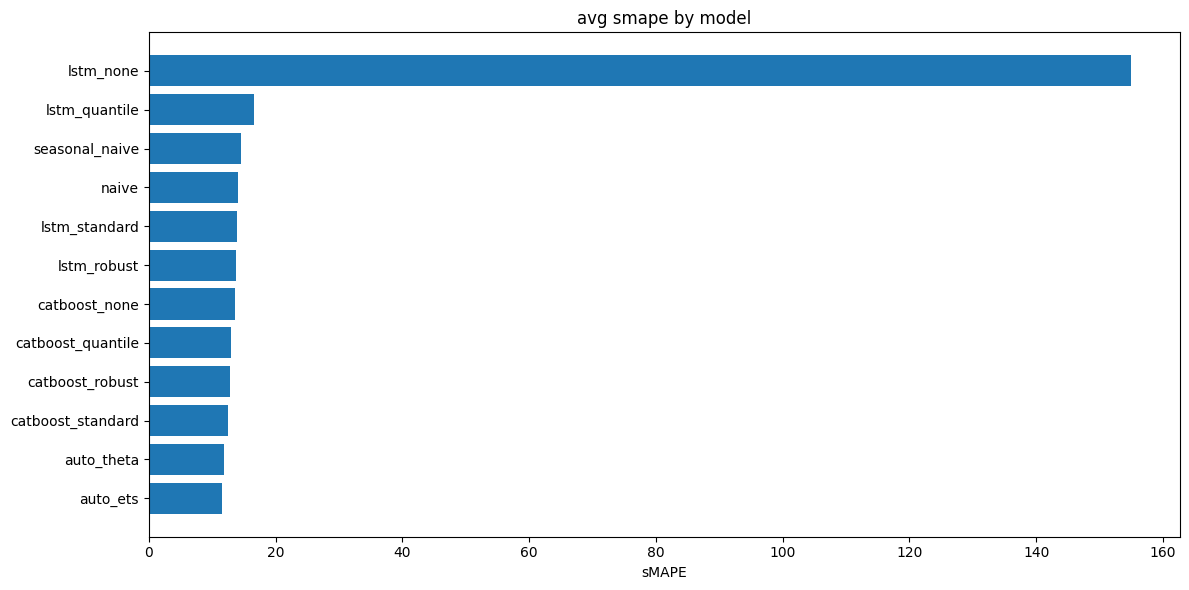

In [64]:
plt.figure(figsize=(12, 6))
summary_sorted = summary_table.sort_values("smape")
plt.barh(summary_sorted["model"], summary_sorted["smape"])
plt.xlabel("sMAPE")
plt.title("avg smape by model")
plt.tight_layout()
plt.show()

### 13.2 sMAPE распределение

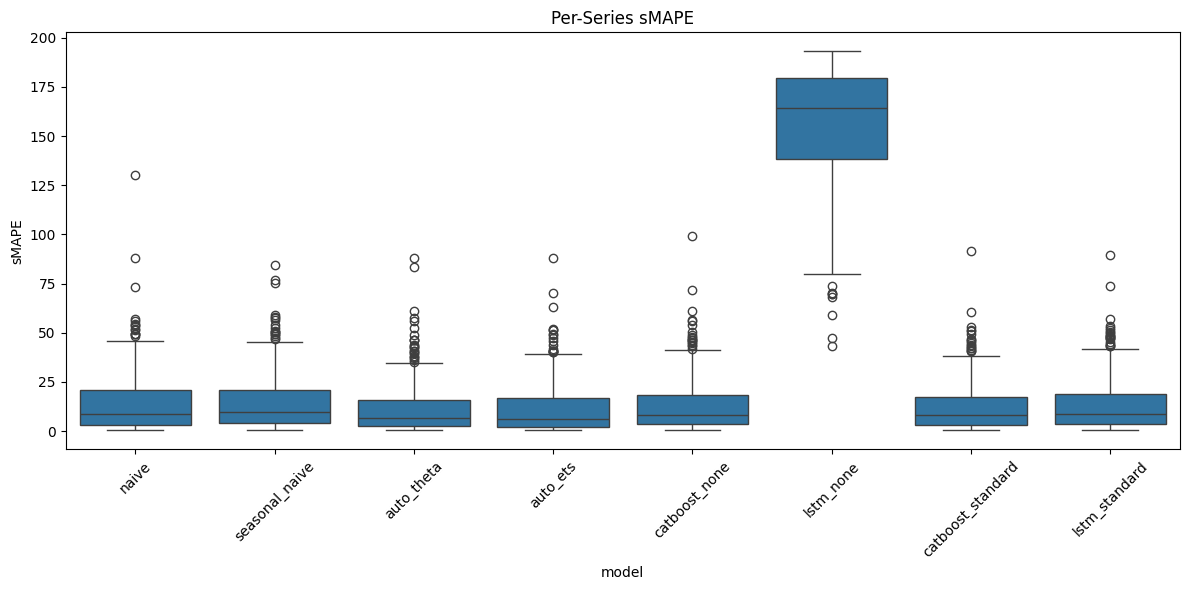

In [65]:
key_models = ["naive", "seasonal_naive", "auto_theta", "auto_ets", "catboost_none", "catboost_standard", "lstm_none", "lstm_standard"]
key_results = final_results[final_results["model"].isin(key_models)]

if len(key_results) > 0:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=key_results, x="model", y="smape")
    plt.xticks(rotation=45)
    plt.ylabel("sMAPE")
    plt.title("Per-Series sMAPE")
    plt.tight_layout()
    plt.show()

## 14. Save

In [66]:
final_results.to_csv("final_results_per_series.csv", index=False)
print(f"Saved per-series results: {final_results.shape[0]} rows")

summary_table.to_csv("final_results_summary.csv", index=False)
print(f"Saved summary results: {summary_table.shape[0]} models")

Saved per-series results: 3600 rows
Saved summary results: 12 models


In [67]:
print(summary_table)

                model         base_model   scaling          mae       smape
8               naive           baseline      none   584.830848   14.115631
0            auto_ets       baseline_ets      none   447.857170   11.618189
9      seasonal_naive  baseline_seasonal      none   582.659971   14.549141
1          auto_theta     baseline_theta      none   480.439963   11.798300
5       catboost_none           catboost      none   536.741856   13.585900
4   catboost_quantile           catboost  quantile   529.202198   12.934245
3     catboost_robust           catboost    robust   525.235333   12.874562
2   catboost_standard           catboost  standard   509.170267   12.509674
11          lstm_none               lstm      none  4403.935468  154.933281
10      lstm_quantile               lstm  quantile   737.077722   16.608314
6         lstm_robust               lstm    robust   555.092429   13.769951
7       lstm_standard               lstm  standard   564.920929   13.840543
